# DeepFashion BBox Crop Extractor

Extracts product regions from all catalog images using the **ground truth bounding boxes**
provided in the DeepFashion In-Shop dataset annotations.

---

### Motivation

Raw DeepFashion images show a full person wearing one or more clothing items.
For retrieval, we care only about the specific product — not the background or the model.
The dataset ships with human-labelled bounding boxes that tightly enclose each product.
We use these directly instead of running a detector, since ground truth is more reliable.

For the interactive demo (Streamlit), we cannot use ground truth boxes because
user-uploaded images have no annotations — so YOLO handles that case separately.

---

### Approach chosen
Use ground truth annotation boxes for all offline splits (train / gallery / query).
YOLO handles online cropping in the demo application.

---

### Input datasets
- `fashionvirtualsearchdataset` — original full-body images
- `preprocesseddatasetvr` — master_df.csv containing merged annotations and split info

### Outputs produced
- `data/bbox_crops/` — directory of all cropped product images
- `master_crops.csv` — full dataset with crop paths added
- `train_crops.csv`, `query_crops.csv`, `gallery_crops.csv` — per-split subsets

## 1. Load Required Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm

warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Configuration and Directory Setup

In [2]:
# ── Input paths ───────────────────────────────────────────────────────────────
RAW_IMAGE_ROOT = '/kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img'
ANNOTATION_DIR = '/kaggle/input/datasets/akibatra25/fashionpreprocesseddataset'

# ── Output paths ──────────────────────────────────────────────────────────────
WORK_DIR   = '/kaggle/working'
CROPS_ROOT = os.path.join(WORK_DIR, 'data', 'bbox_crops')
os.makedirs(CROPS_ROOT, exist_ok=True)

# ── Crop settings ─────────────────────────────────────────────────────────────
EXTRA_PADDING = 10   # pixels added around each bbox edge before cropping

# ── Verify inputs exist ───────────────────────────────────────────────────────
for name, folder in [('RAW_IMAGE_ROOT', RAW_IMAGE_ROOT), ('ANNOTATION_DIR', ANNOTATION_DIR)]:
    tag = 'Found' if os.path.exists(folder) else 'NOT FOUND'
    print(f'[{tag}] {name}: {folder}')

[Found] RAW_IMAGE_ROOT: /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img
[Found] ANNOTATION_DIR: /kaggle/input/datasets/akibatra25/fashionpreprocesseddataset


## 3. Read Annotation CSV

`master_df.csv` was produced by the preprocessing notebook.
It merges split assignments and bbox coordinates into one table.

In [3]:
records = pd.read_csv(os.path.join(ANNOTATION_DIR, 'master_df.csv'))

print(f'Rows loaded    : {len(records):,}')
print(f'Column names   : {records.columns.tolist()}')
print()

print('Records per split:')
print(records['split'].value_counts().to_string())
print()

print('Records per clothing type  (1=upper body, 2=lower body, 3=full body):')
print(records['clothes_type'].value_counts().sort_index().to_string())
print()

records.head()

Rows loaded    : 52,712
Column names   : ['image_name', 'item_id', 'split', 'clothes_type', 'pose_type', 'x1', 'y1', 'x2', 'y2']

Records per split:
split
train      25882
query      14218
gallery    12612

Records per clothing type  (1=upper body, 2=lower body, 3=full body):
clothes_type
1    33487
2    10494
3     8731



,image_name,item_id,split,clothes_type,pose_type,x1,y1,x2,y2
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train,3,1,65,45,233,252
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train,3,2,112,41,168,247
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train,3,4,89,34,169,167
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train,3,5,73,40,194,251
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train,2,1,51,122,160,210


## 4. Helper Functions

In [4]:
def resolve_image_path(img_name):
    """Build the full path to a raw source image."""
    # image_name may start with 'img/' — strip that prefix
    clean = img_name[4:] if img_name.startswith('img/') else img_name
    return os.path.join(RAW_IMAGE_ROOT, clean)


def resolve_crop_path(img_name):
    """Build the save path for a cropped image, mirroring the source structure."""
    clean = img_name[4:] if img_name.startswith('img/') else img_name
    return os.path.join(CROPS_ROOT, clean)


def extract_and_save_crop(pil_img, x1, y1, x2, y2, dest_path, pad=EXTRA_PADDING):
    """
    Crop a region from pil_img using the given bbox, apply padding,
    clamp to image bounds, and save to dest_path.
    """
    w, h = pil_img.size
    left   = max(0, int(x1) - pad)
    top    = max(0, int(y1) - pad)
    right  = min(w, int(x2) + pad)
    bottom = min(h, int(y2) + pad)

    region = pil_img.crop((left, top, right, bottom))
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    region.save(dest_path, quality=95)
    return region


# Quick sanity check on helper functions
sample_row = records.iloc[0]
src  = resolve_image_path(sample_row['image_name'])
dest = resolve_crop_path(sample_row['image_name'])
print(f'Sample image_name : {sample_row["image_name"]}')
print(f'Resolved src path : {src}')
print(f'File exists       : {os.path.exists(src)}')
print(f'Bbox coords       : x1={sample_row["x1"]}  y1={sample_row["y1"]}  x2={sample_row["x2"]}  y2={sample_row["y2"]}')

Sample image_name : img/WOMEN/Dresses/id_00000002/02_1_front.jpg
Resolved src path : /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_1_front.jpg
File exists       : True
Bbox coords       : x1=65  y1=45  x2=233  y2=252


## 5. Visualise Ground Truth Boxes Before Cropping

Draw annotation rectangles on a few sample images to verify they
tightly enclose the intended clothing item.

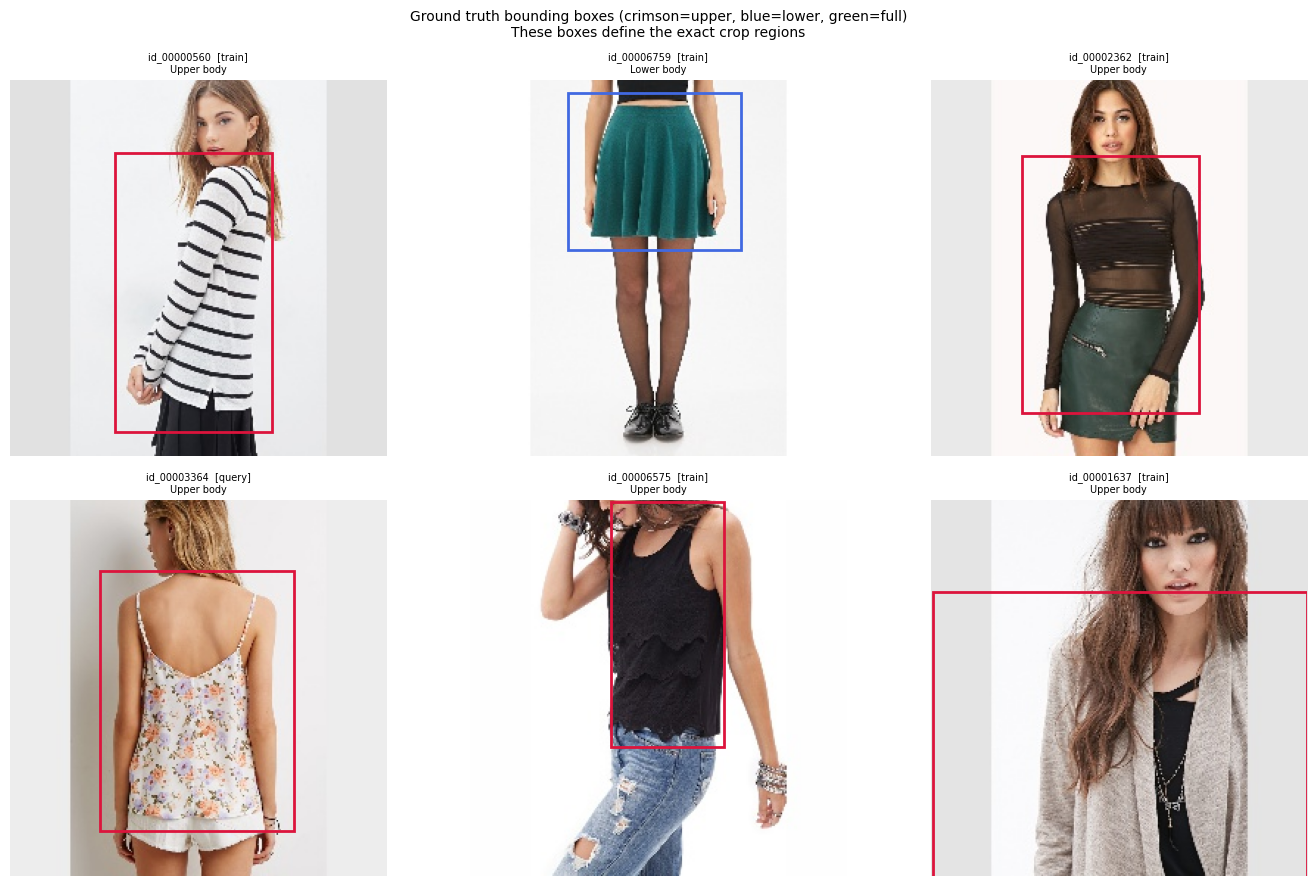

In [5]:
TYPE_LABELS = {1: 'Upper body', 2: 'Lower body', 3: 'Full body'}
BOX_COLORS  = {1: 'crimson', 2: 'royalblue', 3: 'seagreen'}

preview_rows = records.sample(6, random_state=99)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (_, row) in enumerate(preview_rows.iterrows()):
    src_path = resolve_image_path(row['image_name'])
    if not os.path.exists(src_path):
        axes[idx].axis('off')
        continue

    img   = Image.open(src_path).convert('RGB')
    color = BOX_COLORS.get(row['clothes_type'], 'gray')
    rect  = patches.Rectangle(
        (row['x1'], row['y1']),
        row['x2'] - row['x1'],
        row['y2'] - row['y1'],
        linewidth=2, edgecolor=color, facecolor='none'
    )
    axes[idx].imshow(img)
    axes[idx].add_patch(rect)
    lbl = TYPE_LABELS.get(row['clothes_type'], 'unknown')
    axes[idx].set_title(f"{row['item_id']}  [{row['split']}]\n{lbl}", fontsize=7)
    axes[idx].axis('off')

plt.suptitle(
    'Ground truth bounding boxes (crimson=upper, blue=lower, green=full)\n'
    'These boxes define the exact crop regions',
    fontsize=10
)
plt.tight_layout()
plt.show()

## 6. Crop All Images Using Annotation BBoxes

For every record in the dataset:
1. Resolve source image path
2. Apply bbox crop with padding
3. Save to the mirrored output directory

Already-existing crops are skipped so the cell is safe to re-run.
No GPU required — pure PIL operations.
Expected runtime: **5–8 minutes** for all 52,712 images.

In [6]:
saved_paths   = []
error_list    = []
n_new         = 0
n_skipped     = 0

for _, entry in tqdm(records.iterrows(), total=len(records), desc='Cropping images'):
    src_path  = resolve_image_path(entry['image_name'])
    dest_path = resolve_crop_path(entry['image_name'])
    saved_paths.append(dest_path)

    # Skip if already done
    if os.path.exists(dest_path):
        n_skipped += 1
        continue

    if not os.path.exists(src_path):
        error_list.append(entry['image_name'])
        continue

    try:
        pil_img = Image.open(src_path).convert('RGB')
        extract_and_save_crop(
            pil_img,
            entry['x1'], entry['y1'],
            entry['x2'], entry['y2'],
            dest_path
        )
        n_new += 1
    except Exception as err:
        error_list.append(entry['image_name'])

print(f'Newly cropped    : {n_new:,}')
print(f'Already on disk  : {n_skipped:,}')
print(f'Errors           : {len(error_list):,}')

Cropping images: 100%|██████████| 52712/52712 [04:32<00:00, 193.39it/s]

Newly cropped    : 52,712
Already on disk  : 0
Errors           : 0


## 7. Side-by-Side Comparison: Original vs Cropped

The cropped image should contain only the specific clothing item,
with the person's face, legs, and background removed.

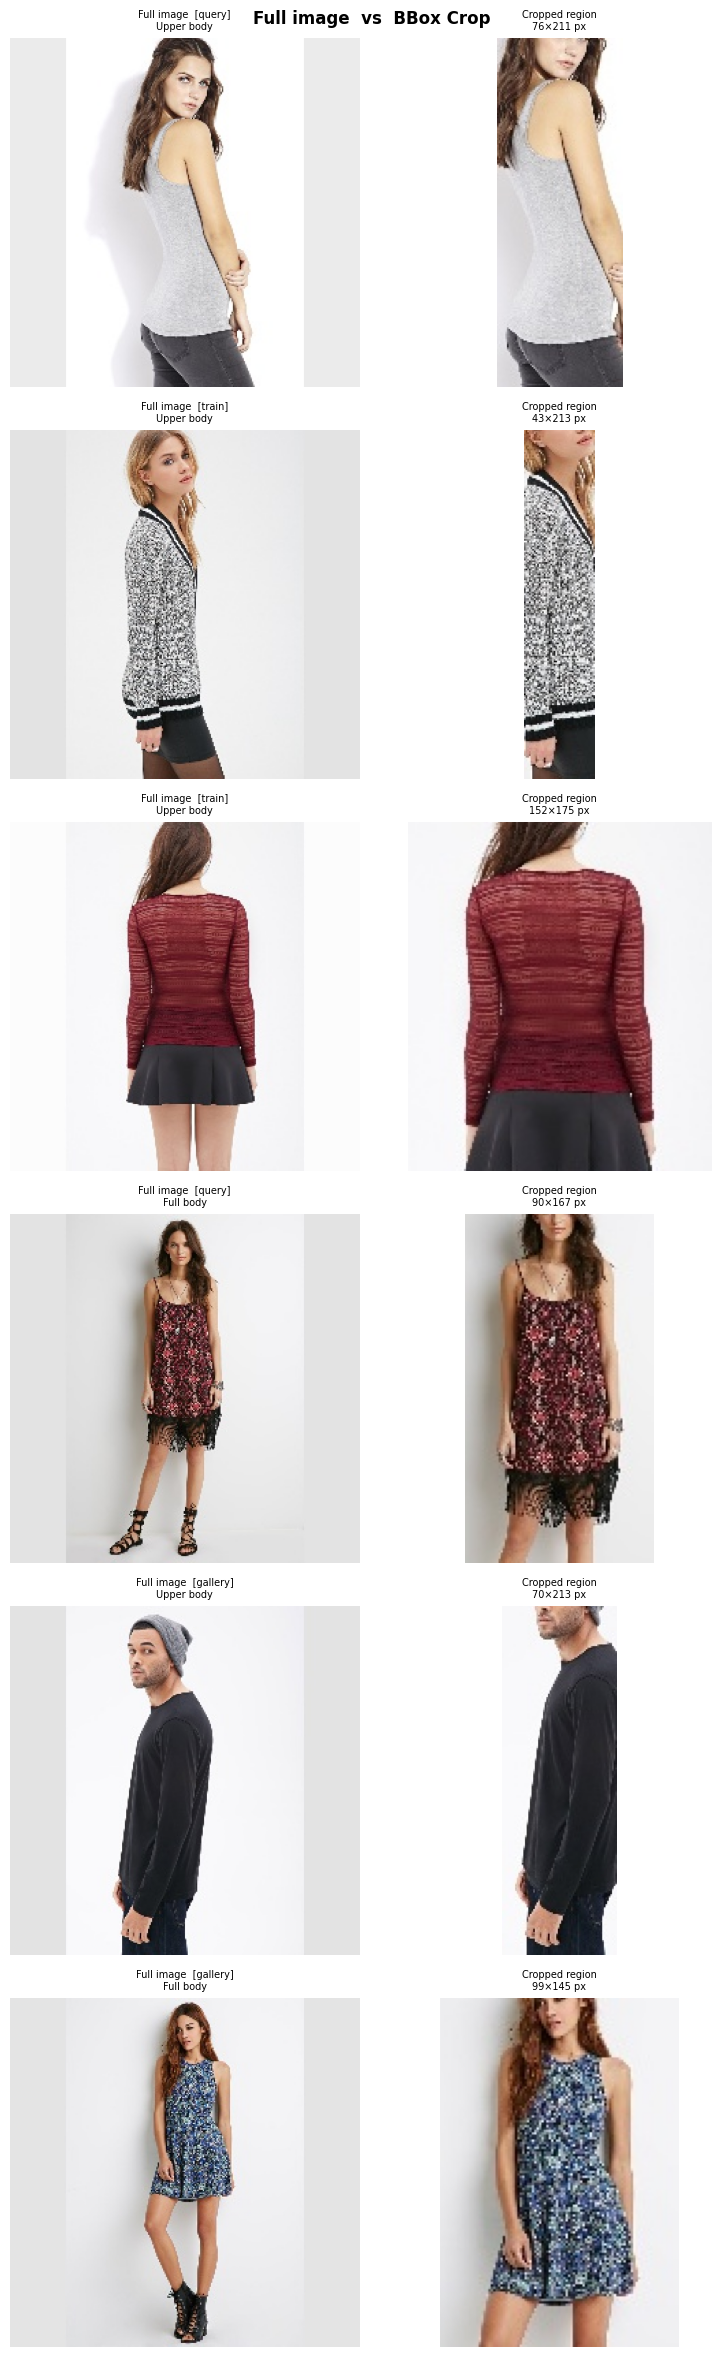

In [7]:
records['crop_path']   = saved_paths
records['crop_exists'] = records['crop_path'].apply(os.path.exists)

check_rows = records[records['crop_exists']].sample(6, random_state=7)

fig, axes = plt.subplots(6, 2, figsize=(8, 24))

for i, (_, row) in enumerate(check_rows.iterrows()):
    original = Image.open(resolve_image_path(row['image_name'])).convert('RGB')
    cropped  = Image.open(row['crop_path']).convert('RGB')
    category = TYPE_LABELS.get(row['clothes_type'], '?')

    axes[i][0].imshow(original)
    axes[i][0].set_title(f'Full image  [{row["split"]}]\n{category}', fontsize=7)
    axes[i][0].axis('off')

    axes[i][1].imshow(cropped)
    axes[i][1].set_title(f'Cropped region\n{cropped.size[0]}×{cropped.size[1]} px', fontsize=7)
    axes[i][1].axis('off')

plt.suptitle('Full image  vs  BBox Crop', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Export Output CSVs

In [8]:
records['crop_method'] = 'annotation_bbox'

# Save master (all splits combined)
records.to_csv(os.path.join(WORK_DIR, 'master_crops.csv'), index=False)

# Save per-split CSVs
for partition in ['train', 'query', 'gallery']:
    subset = records[records['split'] == partition].reset_index(drop=True)
    out_path = os.path.join(WORK_DIR, f'{partition}_crops.csv')
    subset.to_csv(out_path, index=False)
    n_found = subset['crop_exists'].sum()
    print(f'{partition}_crops.csv : {len(subset):,} rows  |  crops on disk: {n_found:,}')

print(f'\nmaster_crops.csv   : {len(records):,} rows')
print(f'Total crops on disk: {records["crop_exists"].sum():,} / {len(records):,}')

train_crops.csv : 25,882 rows  |  crops on disk: 25,882
query_crops.csv : 14,218 rows  |  crops on disk: 14,218
gallery_crops.csv : 12,612 rows  |  crops on disk: 12,612

master_crops.csv   : 52,712 rows
Total crops on disk: 52,712 / 52,712


## 9. Summary

In [9]:
total   = len(records)
success = int(records['crop_exists'].sum())
failed  = len(error_list)

print('=' * 57)
print('         BBOX CROP EXTRACTION — DONE')
print('=' * 57)
print(f'  Cropping strategy    : Ground truth annotation bbox')
print(f'  Total images         : {total:,}')
print(f'  Successfully cropped : {success:,}')
print(f'  Failed / missing     : {failed:,}')
print(f'  Padding applied      : {EXTRA_PADDING} px per edge')
print()
print('  Files to save as Kaggle dataset:')
print('    master_crops.csv')
print('    train_crops.csv')
print('    query_crops.csv')
print('    gallery_crops.csv')
print('    data/bbox_crops/    <- all cropped images')
print()
print('  Note on online pipeline:')
print('    User image in Streamlit -> YOLO -> crop -> CLIP')
print()
print('  Next step: BLIP-2 Captioning notebook')
print('=' * 57)

         BBOX CROP EXTRACTION — DONE
  Cropping strategy    : Ground truth annotation bbox
  Total images         : 52,712
  Successfully cropped : 52,712
  Failed / missing     : 0
  Padding applied      : 10 px per edge

  Files to save as Kaggle dataset:
    master_crops.csv
    train_crops.csv
    query_crops.csv
    gallery_crops.csv
    data/bbox_crops/    <- all cropped images

  Note on online pipeline:
    User image in Streamlit -> YOLO -> crop -> CLIP

  Next step: BLIP-2 Captioning notebook
